In [21]:
!pip install transformers datasets einops matplotlib

In [22]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import time
import math

from transformers import GPT2LMHeadModel, GPT2Tokenizer
from datasets import load_dataset
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.amp import autocast, GradScaler

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [25]:
baseline_model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

baseline_model.eval()

print("Baseline GPT-2 loaded")

Baseline GPT-2 loaded


In [26]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())

In [27]:
dataset = load_dataset("wikitext", "wikitext-2-raw-v1")

In [29]:
def tokenize_function(examples):

    return tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

tokenized_dataset = dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=["text"]
)

tokenized_dataset.set_format("torch")

In [31]:
train_loader = DataLoader(
    tokenized_dataset["train"].select(range(2000)),
    batch_size=16
)

eval_loader = DataLoader(
    tokenized_dataset["validation"].select(range(500)),
    batch_size=16
)

In [32]:
def evaluate_perplexity(model, loader):

    model.eval()

    total_loss = 0
    steps = 0

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            labels = input_ids.clone()
            labels[attention_mask == 0] = -100

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            total_loss += outputs.loss.item()
            steps += 1

    return math.exp(total_loss / steps)

In [33]:
baseline_ppl = evaluate_perplexity(baseline_model, eval_loader)

print("Baseline Perplexity:", baseline_ppl)

Baseline Perplexity: 60.27171013912783


In [34]:
start = time.time()

_ = evaluate_perplexity(baseline_model, eval_loader)

baseline_time = time.time() - start

print("Baseline inference time:", baseline_time)

Baseline inference time: 3.758037805557251


In [35]:
def kronecker_rank_r(W, m1, m2, n1, n2, rank):

    W = W.reshape(m1, m2, n1, n2)
    W = W.permute(0,2,1,3).reshape(m1*n1, m2*n2)

    U,S,Vh = torch.linalg.svd(W, full_matrices=False)

    A_list = []
    B_list = []

    for r in range(rank):

        u = U[:,r]
        v = Vh[r,:]
        s = S[r]

        A = (u*math.sqrt(s)).reshape(m1,n1)
        B = (v*math.sqrt(s)).reshape(m2,n2)

        A_list.append(A)
        B_list.append(B)

    return A_list, B_list

In [36]:
class KronLinear(nn.Module):

    def __init__(self, A_list, B_list, bias):

        super().__init__()

        self.A_list = nn.ParameterList([nn.Parameter(A) for A in A_list])
        self.B_list = nn.ParameterList([nn.Parameter(B) for B in B_list])

        self.bias = nn.Parameter(bias.clone())

    def forward(self, x):

        batch, seq, dim = x.shape

        result = 0

        for A,B in zip(self.A_list,self.B_list):

            W = torch.kron(A,B)

            result += torch.matmul(x, W.t())

        return result + self.bias

In [37]:
def compress_layer_axb(model, layer_idx, rank):

    block = model.transformer.h[layer_idx]

    W_fc = block.mlp.c_fc.weight.data.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    A_list,B_list = kronecker_rank_r(
        W_fc,
        48,64,
        12,64,
        rank
    )

    block.mlp.c_fc = KronLinear(A_list,B_list,b_fc)

    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    A_list,B_list = kronecker_rank_r(
        W_proj,
        12,64,
        48,64,
        rank
    )

    block.mlp.c_proj = KronLinear(A_list,B_list,b_proj)

In [38]:
def build_axb_model(rank):

    model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

    for i in range(12):

        compress_layer_axb(model,i,rank)

    model.eval()

    return model

In [39]:
def kronecker_abc(W, m1,m2,m3,n1,n2,n3):

    W = W.reshape(m1,m2,m3,n1,n2,n3)

    W = W.permute(0,3,1,4,2,5).reshape(m1*n1,m2*n2*m3*n3)

    U,S,Vh = torch.linalg.svd(W,full_matrices=False)

    u = U[:,0]
    v = Vh[0,:]
    s = S[0]

    A = (u*math.sqrt(s)).reshape(m1,n1)

    B = torch.randn(m2,n2).to(device)
    C = torch.randn(m3,n3).to(device)

    return A,B,C

In [40]:
def kronecker_abc(W, m1,m2,m3,n1,n2,n3):

    W = W.reshape(m1,m2,m3,n1,n2,n3)

    W = W.permute(0,3,1,4,2,5).reshape(m1*n1,m2*n2*m3*n3)

    U,S,Vh = torch.linalg.svd(W,full_matrices=False)

    u = U[:,0]
    v = Vh[0,:]
    s = S[0]

    A = (u*math.sqrt(s)).reshape(m1,n1)

    B = torch.randn(m2,n2).to(device)
    C = torch.randn(m3,n3).to(device)

    return A,B,C

In [41]:
def compress_layer_abc(model,layer_idx):

    block = model.transformer.h[layer_idx]

    W_fc = block.mlp.c_fc.weight.data.T.to(device)
    b_fc = block.mlp.c_fc.bias.data.to(device)

    A,B,C = kronecker_abc(
        W_fc,
        3,16,64,
        3,16,16
    )

    block.mlp.c_fc = KronABCLinear(A,B,C,b_fc)

    W_proj = block.mlp.c_proj.weight.data.to(device)
    b_proj = block.mlp.c_proj.bias.data.to(device)

    A,B,C = kronecker_abc(
        W_proj,
        3,16,16,
        3,16,64
    )

    block.mlp.c_proj = KronABCLinear(A,B,C,b_proj)

In [42]:
def build_abc_model():

    model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

    for i in range(12):

        compress_layer_abc(model,i)

    model.eval()

    return model

In [43]:
ranks = [1,2,4]

In [44]:
axb_results = []

for r in ranks:

    print("Running AxB rank",r)

    start = time.time()

    model = build_axb_model(r)

    compression_time = time.time()-start

    ppl = evaluate_perplexity(model,eval_loader)

    params = count_parameters(model)

    axb_results.append((r,params,ppl,compression_time))

Running AxB rank 1
Running AxB rank 2
Running AxB rank 4


In [48]:
start = time.time()

abc_model = build_abc_model()

abc_time = time.time()-start

abc_ppl = evaluate_perplexity(abc_model,eval_loader)

abc_params = count_parameters(abc_model)

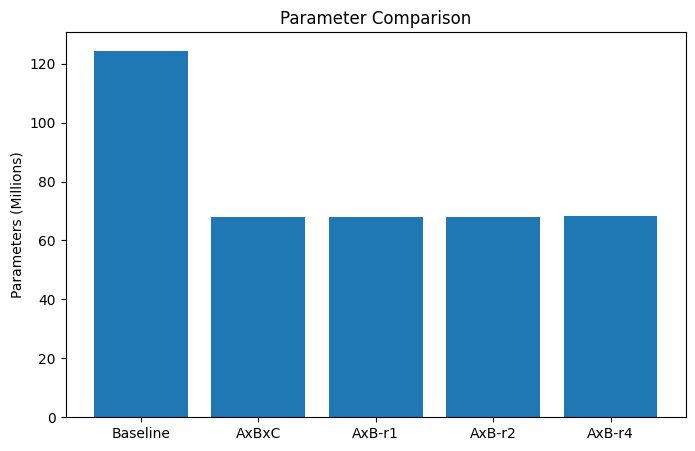

In [46]:
models = ["Baseline","AxBxC"]

params = [count_parameters(baseline_model),abc_params]

for r,p,_,_ in axb_results:

    models.append(f"AxB-r{r}")
    params.append(p)

plt.figure(figsize=(8,5))

plt.bar(models,[p/1e6 for p in params])

plt.ylabel("Parameters (Millions)")
plt.title("Parameter Comparison")

plt.show()

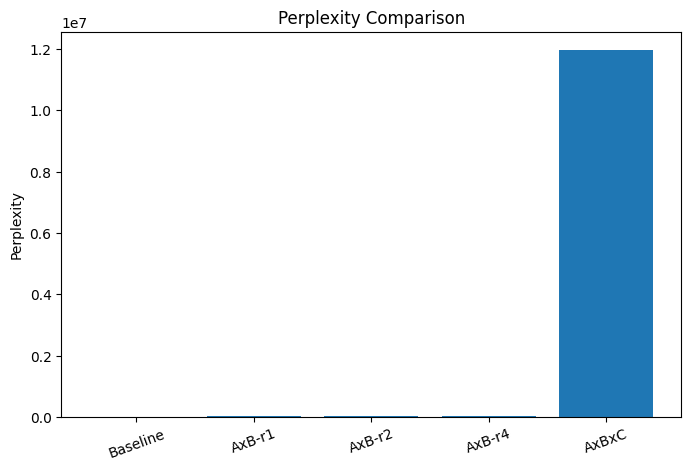

In [49]:
models = ["Baseline"]

ppls = [baseline_ppl]

for r,_,p,_ in axb_results:

    models.append(f"AxB-r{r}")
    ppls.append(p)

models.append("AxBxC")
ppls.append(abc_ppl)

plt.figure(figsize=(8,5))

plt.bar(models,ppls)

plt.ylabel("Perplexity")
plt.title("Perplexity Comparison")

plt.xticks(rotation=20)

plt.show()

In [50]:
print("\nEXPERIMENT RESULTS\n")

print("Baseline Params:",count_parameters(baseline_model))
print("Baseline PPL:",baseline_ppl)
print("Baseline Time:",baseline_time)

print("\nAxB Results")

for r,p,ppl,t in axb_results:

    print(f"Rank {r}: Params={p} PPL={ppl} Time={t}")

print("\nAxBxC")

print("Params:",abc_params)
print("PPL:",abc_ppl)
print("Time:",abc_time)


EXPERIMENT RESULTS

Baseline Params: 124439808
Baseline PPL: 60.27171013912783
Baseline Time: 3.758037805557251

AxB Results
Rank 1: Params=67928832 PPL=46207.672853429154 Time=2.394725799560547
Rank 2: Params=68040960 PPL=47690.50974650459 Time=2.7931065559387207
Rank 4: Params=68265216 PPL=43053.51371861333 Time=2.3725619316101074

AxBxC
Params: 67847640
PPL: 11963538.920700155
Time: 1.769876480102539
